Nature Run と観測を準備中...
ヒートマップ作成のための並列計算を開始します (全 4641 通り)
CPUの全コアがフル稼働します。数分お待ちください...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   45.9s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 2146 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done 3010 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done 3496 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 4018 tasks      | elapsed: 11.4min
[Parallel(n_jobs=-1)]: Done 4576 tasks      | e

全計算完了！ 所要時間: 785.97 秒


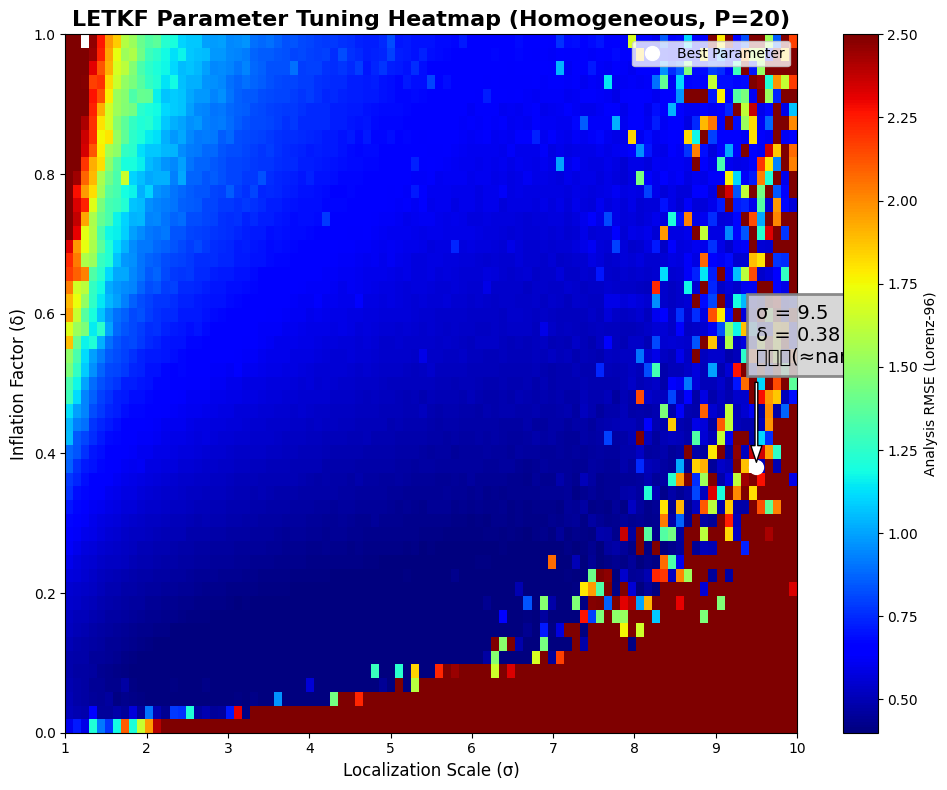

In [4]:
# =====================================================================
# LETKF パラメータチューニング 全探索ヒートマップ (Homogeneous P=20版)
# =====================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# --- 1. 基本パラメータ設定 ---
N = 40
F = 8.0
dt = 0.01
sampling_interval = 5
m = 8
steps_spin_up = 730
total_cycles = 1400  # 評価サイクル (1400回)

# --- 2. CPU用 モデル・局所化関数 ---
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M_fast(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def R_localization_inv(sigma, obs_indices):
    P = len(obs_indices)
    i = np.arange(N)[:, None]
    j_obs = np.array(obs_indices)[None, :]
    d = np.minimum(np.abs(i - j_obs), N - np.abs(i - j_obs))
    cutoff = np.sqrt(10.0 / 3.0) * sigma * 2.0
    L = np.where(d < cutoff, np.exp(- (d**2) / (2 * sigma**2)), 0.0)
    orig_r_inv = np.ones(P) 
    R_loc_inv = orig_r_inv[None, :] * L
    return R_loc_inv

# --- 3. LETKF評価関数 (1回の試行 / エラー回避・堅牢化版) ---
def evaluate_letkf(delta, sigma, x_0, true_states, full_noise, obs_indices):
    P = len(obs_indices)
    num_cycles = true_states.shape[0]
    
    H_mat = np.zeros((P, N), dtype=np.float64)
    H_mat[np.arange(P), obs_indices] = 1.0
    R_loc_inv = R_localization_inv(sigma, obs_indices) 
    
    np.random.seed(42)
    init_noise = np.random.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    X_a = x_0[:, None] + init_noise
    record_rmse = np.zeros(num_cycles)
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    
    # ★追加: 無茶なパラメータでエラーが出ても止まらせない try-except ブロック
    try:
        for t in range(num_cycles):
            y_o = true_states[t, obs_indices] + full_noise[t, obs_indices]
            
            X_b = M_fast(X_a, dt, sampling_interval)
            x_b_mean = np.mean(X_b, axis=1) 
            
            Z_b = (X_b - x_b_mean[:, None]) * inflation_factor
            Y_b = H_mat @ Z_b                           
            innovation = y_o - H_mat @ x_b_mean         
            
            YY_b = Y_b[:, :, None] * Y_b[:, None, :]    
            P_a_tilde_inv_batch = np.tensordot(R_loc_inv, YY_b, axes=(1, 0)) + np.eye(m)
            
            # ★修正点1: 浮動小数点の丸め誤差による非対称化をリセットし、対称行列を強制する
            P_a_tilde_inv_batch = (P_a_tilde_inv_batch + P_a_tilde_inv_batch.swapaxes(1, 2)) / 2.0
            
            # これで eigh が確実に収束するようになります
            D_batch, C_batch = np.linalg.eigh(P_a_tilde_inv_batch)
            D_inv = 1.0 / D_batch
            D_inv_sqrt = 1.0 / np.sqrt(D_batch)
            
            P_a_tilde_batch = (C_batch * D_inv[:, None, :]) @ C_batch.swapaxes(1, 2)
            W_batch = (C_batch * D_inv_sqrt[:, None, :]) @ C_batch.swapaxes(1, 2)
            
            Y_inn = Y_b * innovation[:, None]           
            v_batch = np.tensordot(R_loc_inv, Y_inn, axes=(1, 0)) 
            
            w_batch = (P_a_tilde_batch @ v_batch[:, :, None]).squeeze(-1)
            T_batch = w_batch[:, :, None] + np.sqrt(m - 1.0) * W_batch
            
            Z_b_T = (Z_b[:, None, :] @ T_batch).squeeze(1)
            X_a = x_b_mean[:, None] + Z_b_T
                
            x_a_mean = np.mean(X_a, axis=1)
            rmse_val = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
            
            # ★修正点2: 発散(NaNや大きすぎるエラー)を検知したら、即座に評価を打ち切る
            if np.isnan(rmse_val) or rmse_val > 100.0:
                return np.nan
                
            record_rmse[t] = rmse_val
            
        return np.mean(record_rmse[50:])
        
    except np.linalg.LinAlgError:
        # 固有値分解がどうしても無理な極端なパラメータだった場合は、エラーで落とさずに NaN を返す
        return np.nan

# --- 4. 事前準備 (真値作成) ---
print("Nature Run と観測を準備中...")
x = np.full(N, F, dtype=np.float64)
x[19] += 0.001
x = M_fast(x, dt, steps_spin_up)
x_0 = x.copy()

true_states = np.zeros((total_cycles, N), dtype=np.float64)
for t in range(total_cycles):
    x = M_fast(x, dt, sampling_interval)
    true_states[t] = x.copy()

np.random.seed(67)
full_noise = np.random.normal(loc=0.0, scale=1.0, size=true_states.shape)

# ★ 変更点：全点観測から、Homogeneous（均等観測 P=20）に変更
P = 20
obs_indices = np.linspace(0, N, P, endpoint=False, dtype=int).tolist()

# --- 5. 探索パラメータのメッシュ構築 (画像と同じ解像度) ---
delta_list = np.linspace(0.0, 1.0, 51)   # 0.0 から 1.0 (51点)
sigma_list = np.linspace(1.0, 10.0, 91)  # 1.0 から 10.0 (91点)
tasks = [(d, s) for d in delta_list for s in sigma_list]

print(f"ヒートマップ作成のための並列計算を開始します (全 {len(tasks)} 通り)")
print("CPUの全コアがフル稼働します。数分お待ちください...")
start_time = time.time()

# joblibで並列計算 (n_jobs=-1 で全コア使用)
results = Parallel(n_jobs=-1, verbose=5)(
    delayed(evaluate_letkf)(d, s, x_0, true_states, full_noise, obs_indices) for d, s in tasks
)

print(f"全計算完了！ 所要時間: {time.time() - start_time:.2f} 秒")

# --- 6. ヒートマップの描画 (画像のデザインを再現) ---
rmse_matrix = np.array(results).reshape(len(delta_list), len(sigma_list))

# NaNや極端に大きい値をクリップして色を整える (画像に合わせ最大2.5)
rmse_clipped = np.clip(rmse_matrix, 0.4, 2.5)

# 最良のパラメータ（最小RMSE）を見つける
min_idx = np.unravel_index(np.argmin(rmse_matrix), rmse_matrix.shape)
best_delta = delta_list[min_idx[0]]
best_sigma = sigma_list[min_idx[1]]
best_rmse = rmse_matrix[min_idx]

fig, ax = plt.subplots(figsize=(10, 8))

# origin='lower' で delta_list が下から上に向かって増えるように描画
im = ax.imshow(
    rmse_clipped,
    extent=[sigma_list[0], sigma_list[-1], delta_list[0], delta_list[-1]],
    origin='lower',
    aspect='auto',
    cmap='jet', # 画像と同じサーモグラフィ風のカラーマップ
    vmin=0.4, vmax=2.5
)

# カラーバーの追加
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Analysis RMSE (Lorenz-96)')

# 最良パラメータの位置に白丸をプロット
ax.plot(best_sigma, best_delta, 'wo', markersize=10, label='Best Parameter')

# 画像のような吹き出しを追加
bbox_props = dict(boxstyle="square,pad=0.5", fc="lightgray", ec="gray", lw=2, alpha=0.9)
ax.annotate(
    f'σ = {best_sigma:.1f}\nδ = {best_delta:.2f}\nで最小(≈{best_rmse:.3f})',
    xy=(best_sigma, best_delta),
    xytext=(best_sigma, best_delta + 0.15), # 少し上にずらす
    arrowprops=dict(facecolor='white', shrink=0.05, width=2, headwidth=8),
    bbox=bbox_props,
    fontsize=14
)

ax.set_xlabel("Localization Scale (σ)", fontsize=12)
ax.set_ylabel("Inflation Factor (δ)", fontsize=12)

# ★ 変更点：タイトルに条件を追記
ax.set_title("LETKF Parameter Tuning Heatmap (Homogeneous, P=20)", fontsize=16, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

In [3]:
# =====================================================================
# 観測ネットワーク依存性: LETKFパラメータ最適化ヒートマップ比較
# =====================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# --- 1. 基本パラメータ設定 ---
N = 40
F = 8.0
dt = 0.01
sampling_interval = 5
m = 8
steps_spin_up = 7300
total_cycles = 1460  # 評価サイクル

# --- 2. CPU用 モデル・局所化関数 ---
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M_fast(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def R_localization_inv(sigma, obs_indices):
    P = len(obs_indices)
    i = np.arange(N)[:, None]
    j_obs = np.array(obs_indices)[None, :]
    d = np.minimum(np.abs(i - j_obs), N - np.abs(i - j_obs))
    cutoff = np.sqrt(10.0 / 3.0) * sigma * 2.0
    L = np.where(d < cutoff, np.exp(- (d**2) / (2 * sigma**2)), 0.0)
    orig_r_inv = np.ones(P) 
    R_loc_inv = orig_r_inv[None, :] * L
    return R_loc_inv

# --- 3. LETKF評価関数 (1回の試行) ---
def evaluate_letkf(delta, sigma, x_0, true_states, full_noise, obs_indices):
    P = len(obs_indices)
    num_cycles = true_states.shape[0]
    
    H_mat = np.zeros((P, N), dtype=np.float64)
    H_mat[np.arange(P), obs_indices] = 1.0
    R_loc_inv = R_localization_inv(sigma, obs_indices) 
    
    np.random.seed(42)
    init_noise = np.random.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    X_a = x_0[:, None] + init_noise
    record_rmse = np.zeros(num_cycles)
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    
    for t in range(num_cycles):
        y_o = true_states[t, obs_indices] + full_noise[t, obs_indices]
        
        X_b = M_fast(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1) 
        
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor
        Y_b = H_mat @ Z_b                           
        innovation = y_o - H_mat @ x_b_mean         
        
        YY_b = Y_b[:, :, None] * Y_b[:, None, :]    
        P_a_tilde_inv_batch = np.tensordot(R_loc_inv, YY_b, axes=(1, 0)) + np.eye(m)
        
        D_batch, C_batch = np.linalg.eigh(P_a_tilde_inv_batch)
        D_inv = 1.0 / D_batch
        D_inv_sqrt = 1.0 / np.sqrt(D_batch)
        
        P_a_tilde_batch = (C_batch * D_inv[:, None, :]) @ C_batch.swapaxes(1, 2)
        W_batch = (C_batch * D_inv_sqrt[:, None, :]) @ C_batch.swapaxes(1, 2)
        
        Y_inn = Y_b * innovation[:, None]           
        v_batch = np.tensordot(R_loc_inv, Y_inn, axes=(1, 0)) 
        
        w_batch = (P_a_tilde_batch @ v_batch[:, :, None]).squeeze(-1)
        T_batch = w_batch[:, :, None] + np.sqrt(m - 1.0) * W_batch
        
        Z_b_T = (Z_b[:, None, :] @ T_batch).squeeze(1)
        X_a = x_b_mean[:, None] + Z_b_T
            
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        
    return np.mean(record_rmse[50:])

# --- 4. 事前準備 (真値作成) ---
print("Nature Run と観測を準備中...")
x = np.full(N, F, dtype=np.float64)
x[19] += 0.001
x = M_fast(x, dt, steps_spin_up)
x_0 = x.copy()

true_states = np.zeros((total_cycles, N), dtype=np.float64)
for t in range(total_cycles):
    x = M_fast(x, dt, sampling_interval)
    true_states[t] = x.copy()

np.random.seed(67)
full_noise = np.random.normal(loc=0.0, scale=1.0, size=true_states.shape)

# 今回は P=20 で固定して2つのシナリオを比較します
P = 20
idx_homo = np.linspace(0, N, P, endpoint=False, dtype=int).tolist()
idx_dense = np.arange(P).tolist()

# --- 5. 探索パラメータのメッシュ構築 ---
delta_list = np.linspace(0.0, 1.0, 51)   # 51点
sigma_list = np.linspace(1.0, 10.0, 91)  # 91点
tasks = [(d, s) for d in delta_list for s in sigma_list]

print(f"\n【Case 1: Homogeneous (均等観測 P={P})】の並列計算を開始...")
start_time_homo = time.time()
results_homo = Parallel(n_jobs=-1, verbose=5)(
    delayed(evaluate_letkf)(d, s, x_0, true_states, full_noise, idx_homo) for d, s in tasks
)
print(f"=> 完了 (所要時間: {time.time() - start_time_homo:.2f} 秒)\n")

print(f"【Case 2: Dense (偏った観測 P={P})】の並列計算を開始...")
start_time_dense = time.time()
results_dense = Parallel(n_jobs=-1, verbose=5)(
    delayed(evaluate_letkf)(d, s, x_0, true_states, full_noise, idx_dense) for d, s in tasks
)
print(f"=> 完了 (所要時間: {time.time() - start_time_dense:.2f} 秒)\n")


# --- 6. ヒートマップの描画 ---
def plot_heatmap(ax, results_list, title):
    rmse_matrix = np.array(results_list).reshape(len(delta_list), len(sigma_list))
    rmse_clipped = np.clip(rmse_matrix, 0.4, 3.5) # Denseは誤差が大きめに出るため上限を少し広げる
    
    # 最良のパラメータ
    min_idx = np.unravel_index(np.argmin(rmse_matrix), rmse_matrix.shape)
    best_delta = delta_list[min_idx[0]]
    best_sigma = sigma_list[min_idx[1]]
    best_rmse = rmse_matrix[min_idx]
    
    im = ax.imshow(
        rmse_clipped,
        extent=[sigma_list[0], sigma_list[-1], delta_list[0], delta_list[-1]],
        origin='lower', aspect='auto', cmap='jet', vmin=0.4, vmax=3.5
    )
    
    ax.plot(best_sigma, best_delta, 'wo', markersize=10)
    
    bbox_props = dict(boxstyle="square,pad=0.5", fc="lightgray", ec="gray", lw=2, alpha=0.9)
    ax.annotate(
        f'σ = {best_sigma:.1f}\nδ = {best_delta:.2f}\nRMSE ≈ {best_rmse:.3f}',
        xy=(best_sigma, best_delta),
        xytext=(best_sigma, best_delta + 0.15),
        arrowprops=dict(facecolor='white', shrink=0.05, width=2, headwidth=8),
        bbox=bbox_props, fontsize=12
    )
    
    ax.set_xlabel("Localization Scale (σ)", fontsize=12)
    ax.set_ylabel("Inflation Factor (δ)", fontsize=12)
    ax.set_title(title, fontsize=16, fontweight='bold')
    return im

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Case 1: Homogeneous
im_homo = plot_heatmap(axes[0], results_homo, "Case 1: Homogeneous (P=20)")
# Case 2: Dense
im_dense = plot_heatmap(axes[1], results_dense, "Case 2: Dense (P=20)")

# 共通のカラーバーを追加
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im_dense, cax=cbar_ax)
cbar.set_label('Analysis RMSE (Lorenz-96)', fontsize=12)

plt.subplots_adjust(left=0.05, right=0.9)
plt.show()

Nature Run と観測を準備中...

【Case 1: Homogeneous (均等観測 P=20)】の並列計算を開始...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:   47.5s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 2146 tasks      | elapsed:  6.5min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 3010 tasks      | elapsed:  9.2min
[Parallel(n_jobs=-1)]: Done 3496 tasks      | elapsed: 10.7min
[Parallel(n_jobs=-1)]: Done 4018 tasks      | elapsed: 12.3min


LinAlgError: Eigenvalues did not converge

In [10]:
# =====================================================================
# 5. メンバー数 (m) に対する RMSE 感度実験：PO法 vs LETKF
# =====================================================================
import time
import numpy as np
import matplotlib.pyplot as plt

# --- 共通パラメータ ---
N = 40
F = 8.0
dt = 0.01
steps_spin_up = 365 * 20
sampling_interval = 20
test_cycles = 100

H_mat = np.eye(N)
R_mat = np.eye(N)

# --- 1. 基本関数 ---
def lorenz96_fast(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M_fast(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96_fast(x_out, F)
        k2 = lorenz96_fast(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96_fast(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96_fast(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                L[i, j] = 1 - 1/4*r**5 + 1/2*r**4 + 5/8*r**3 - 5/3*r**2
            elif r <= 2.0:
                L[i, j] = 1/12*r**5 - 1/2*r**4 + 5/8*r**3 + 5/3*r**2 - 5*r + 4 - 2/3*(1/r)
    return L

# --- 2. 共通の真値と観測データの生成 ---
print("共通テストデータの生成中...")
x_tmp = np.full(N, F)
x_tmp[19] += 0.001
x_tmp = M_fast(x_tmp, dt, steps_spin_up)

true_states = []
y_o_data = []
rng_obs = np.random.default_rng(seed=123)

for _ in range(test_cycles):
    x_tmp = M_fast(x_tmp, dt, sampling_interval)
    true_states.append(x_tmp.copy())
    y_o_data.append(x_tmp + rng_obs.normal(0.0, 1.0, size=N))

true_states = np.array(true_states)
y_o_data = np.array(y_o_data)

# --- 3. PO法 (EnKF) の実装 ---
def run_EnKF_PO(y_o_data, true_states, m, delta, sigma):
    num_cycles = y_o_data.shape[0]
    L = Gaspari_Cohn_L(sigma)
    rng_enkf = np.random.default_rng(seed=42)
    
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    x_raw_init = np.full(N, F)
    x_raw_init[19] += 0.001
    X_a = M_fast(x_raw_init[:, None] + init_noise, dt, steps_spin_up)
    
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    record_rmse = np.zeros(num_cycles)
    
    for t in range(num_cycles):
        X_b = M_fast(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1, keepdims=True)
        Z_b = (X_b - x_b_mean) * inflation_factor
        
        Y_b = H_mat @ Z_b
        Cov_xy = L * (Z_b @ Y_b.T)
        Cov_yy = L * (Y_b @ Y_b.T)
        Cov_yy = (Cov_yy + Cov_yy.T) / 2.0
        
        K = Cov_xy @ np.linalg.solve(Cov_yy + R_mat, np.eye(N))
        
        E_prime = rng_enkf.normal(0.0, 1.0, size=(N, m))
        E_o = E_prime - np.mean(E_prime, axis=1, keepdims=True)
        
        # 【修正箇所】 y_o_data[t][:, None] で縦ベクトル (40, 1) に変換
        D = (y_o_data[t][:, None] + E_o) - (H_mat @ X_b)
        X_a = X_b + K @ D
        
        record_rmse[t] = np.sqrt(np.mean((np.mean(X_a, axis=1) - true_states[t])**2))
        
    return np.mean(record_rmse[20:])

# --- 4. LETKF の実装 ---
def R_localization_inv(sigma):
    R_loc_inv = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            if d < np.sqrt(10 / 3) * sigma * 2.0:
                R_loc_inv[i, j] = (1.0 / R_mat[j, j]) * np.exp(- (d**2) / (2 * sigma**2))
    return R_loc_inv

def run_LETKF_sim(y_o_data, true_states, m, delta, sigma):
    num_cycles = y_o_data.shape[0]
    R_loc_inv = R_localization_inv(sigma)
    rng_enkf = np.random.default_rng(seed=42)
    
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    x_raw_init = np.full(N, F)
    x_raw_init[19] += 0.001
    X_a = M_fast(x_raw_init[:, None] + init_noise, dt, steps_spin_up)
    
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    record_rmse = np.zeros(num_cycles)
    
    for t in range(num_cycles):
        X_b = M_fast(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor
        Y_b = H_mat @ Z_b
        innovation = y_o_data[t] - H_mat @ x_b_mean
        
        X_a = np.zeros((N, m))
        for i in range(N):
            R_loc_inv_diag = np.diag(R_loc_inv[i, :])
            P_a_tilde_inv = np.eye(m) + (Y_b.T @ R_loc_inv_diag @ Y_b)
            D_eig, C_eig = np.linalg.eigh(P_a_tilde_inv)
            
            P_a_tilde = C_eig @ np.diag(1.0 / D_eig) @ C_eig.T
            W = C_eig @ np.diag(1.0 / np.sqrt(D_eig)) @ C_eig.T
            
            w = P_a_tilde @ Y_b.T @ R_loc_inv_diag @ innovation
            T_mat = w[:, None] + np.sqrt(m - 1.0) * W
            X_a[i, :] = x_b_mean[i] + Z_b[i, :] @ T_mat
            
        record_rmse[t] = np.sqrt(np.mean((np.mean(X_a, axis=1) - true_states[t])**2))
        
    return np.mean(record_rmse[20:])

# --- 5. 実験とプロット (パラメータチューニング・ベスト値プロット版) ---
import itertools

m_test_list = list(range(8, 80, 16)) # 実行時間を考慮し、一旦8飛ばしにしています

# =========================================================
# ▼ 探索するパラメータのリスト (3通り × 3通り = 9通り) ▼
# =========================================================
delta_test_list = [0.05, 0.10, 0.15, 0.20, 0.40, 0.80]
sigma_test_list = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

# itertools.product で 9通りの組み合わせリストを自動生成
param_combinations = list(itertools.product(delta_test_list, sigma_test_list))
# =========================================================

po_best_rmse_results = []
letkf_best_rmse_results = []

print("実験を開始します...")
print(f"メンバー数 {len(m_test_list)} パターン × パラメータ {len(param_combinations)} 通り × 2手法")
print(f"合計 {len(m_test_list) * len(param_combinations) * 2} 回のシミュレーションを実行します。")
print("-" * 60)

for m_val in m_test_list:
    print(f"メンバー数 m = {m_val:2d} を探索中...")
    
    # 最良のRMSEを記録するための変数を無限大(inf)で初期化
    best_rmse_po = float('inf')
    best_rmse_letkf = float('inf')
    
    # どのパラメータがベストだったかを記録（確認用）
    best_params_po = None
    best_params_letkf = None
    
    # 9通りの組み合わせを回す
    for delta_val, sigma_val in param_combinations:
        
        # 1. PO法の実行と評価
        rmse_po = run_EnKF_PO(y_o_data, true_states, m=m_val, delta=delta_val, sigma=sigma_val)
        # より良い(小さい)RMSEが出たら記録を更新
        if rmse_po < best_rmse_po:
            best_rmse_po = rmse_po
            best_params_po = (delta_val, sigma_val)
            
        # 2. LETKFの実行と評価
        rmse_letkf = run_LETKF_sim(y_o_data, true_states, m=m_val, delta=delta_val, sigma=sigma_val)
        # より良い(小さい)RMSEが出たら記録を更新
        if rmse_letkf < best_rmse_letkf:
            best_rmse_letkf = rmse_letkf
            best_params_letkf = (delta_val, sigma_val)

    # 9通りの探索が終わったら、そのメンバー数での「ベストRMSE」をリストに追加
    po_best_rmse_results.append(best_rmse_po)
    letkf_best_rmse_results.append(best_rmse_letkf)
    
    print(f"  └ PO法 最良RMSE: {best_rmse_po:.4f} (delta={best_params_po[0]}, sigma={best_params_po[1]})")
    print(f"  └ LETKF 最良RMSE: {best_rmse_letkf:.4f} (delta={best_params_letkf[0]}, sigma={best_params_letkf[1]})")

print("-" * 60)
print("すべての探索が完了しました！")

# グラフ描画
plt.figure(figsize=(10, 6))

plt.plot(m_test_list, po_best_rmse_results, marker='o', color='blue', linewidth=2, label='EnKF (PO) - Best Tuned')
plt.plot(m_test_list, letkf_best_rmse_results, marker='s', color='red', linewidth=2, label='LETKF - Best Tuned')

plt.xlabel('Ensemble Size (m)', fontsize=12)
plt.ylabel('Best Average RMSE', fontsize=12)
plt.title('Best RMSE vs Ensemble Size (Optimized over 9 Param Combinations)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

共通テストデータの生成中...
実験を開始します...
メンバー数 5 パターン × パラメータ 36 通り × 2手法
合計 360 回のシミュレーションを実行します。
------------------------------------------------------------
メンバー数 m =  8 を探索中...
  └ PO法 最良RMSE: 0.5221 (delta=0.4, sigma=2.0)
  └ LETKF 最良RMSE: 0.4067 (delta=0.4, sigma=4.0)
メンバー数 m = 24 を探索中...
  └ PO法 最良RMSE: 0.3974 (delta=0.4, sigma=6.0)
  └ LETKF 最良RMSE: 0.3520 (delta=0.1, sigma=8.0)
メンバー数 m = 40 を探索中...
  └ PO法 最良RMSE: 0.3564 (delta=0.1, sigma=8.0)
  └ LETKF 最良RMSE: 0.3408 (delta=0.05, sigma=10.0)
メンバー数 m = 56 を探索中...
  └ PO法 最良RMSE: 0.3507 (delta=0.4, sigma=8.0)
  └ LETKF 最良RMSE: 0.3445 (delta=0.05, sigma=6.0)
メンバー数 m = 72 を探索中...


KeyboardInterrupt: 